In [450]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

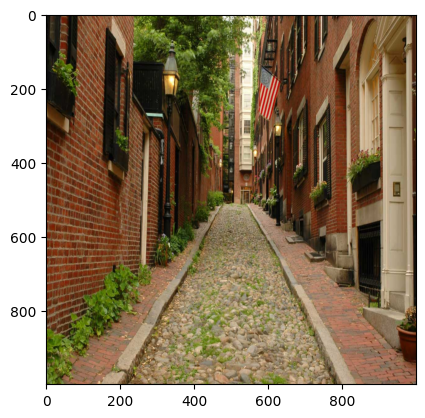

In [451]:
im = cv.resize(cv.imread("../../image_test/acorn-street.jpg"), (1000,1000))
im = cv.cvtColor(im, cv.COLOR_BGR2RGB)
plt.imshow(im)

In [452]:
r,g,b = cv.split(im)

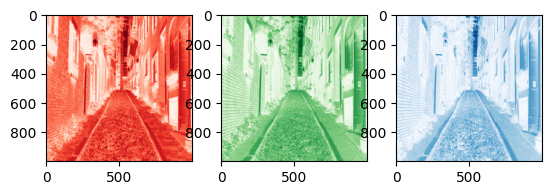

In [453]:
plt.subplot(1,3,1); plt.imshow(r, cmap="Reds")
plt.subplot(1,3,2); plt.imshow(g, cmap="Greens")
plt.subplot(1,3,3); plt.imshow(b, cmap="Blues")

## Umbralization

In [454]:
def umbralization(img, t):
    (X,Y) = img.shape
    zeroes = np.zeros((X,Y))

    for i in range(X):
        for j in range(Y):
            if (img[i,j]> t):
                zeroes[i, j] = 255
            else:
                zeroes[i,j] = 0
    return zeroes
                


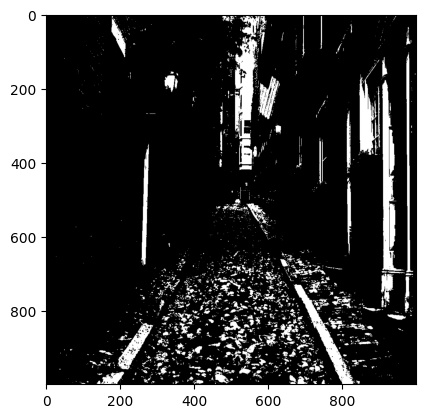

In [455]:
i = umbralization(r, 180)
plt.imshow(i, cmap="gray")

In [456]:
#### kernel for horizontal changes
gx = 1/8*np.array(([-1,0,1],[-2,0,2], [-1,0,1]))
#### kernel for vertical changes
gy = 1/8*np.array(([1,2,1],[0,0,0], [-1,-2,-1]))

### 2d Convolution

In [457]:
def conv2d(img, kernel, bias):
    m,n = kernel.shape
    if(m == n):
        x,y = img.shape
        x = (x - m) + 1
        y = (y - n) + 1
        n_img = np.zeros((x,y))
        for i in range(y):
            for j in range(x):
                n_img[i,j] = np.sum(img[i:i+m, j:j+m]*kernel) + bias
    return n_img

### Running the two filters over the image

In [458]:
img_gx = conv2d(i, gx, 0)
img_gy = conv2d(i, gy, 0)

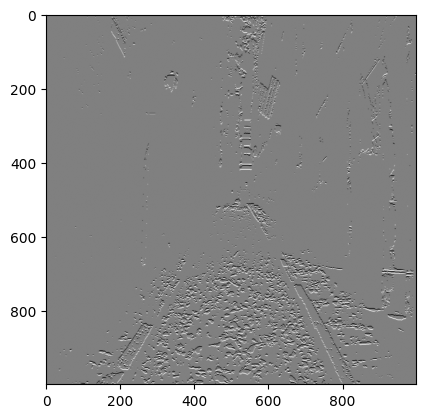

In [459]:
plt.imshow(img_gy, cmap="gray")

### Then we calculate image gradient magnitude

In [460]:
img_gx_i = img_gx.astype(int)
img_gy_i = img_gy.astype(int)

In [461]:
edges = np.sqrt(np.power(img_gx_i, 2) + np.power(img_gy_i, 2))

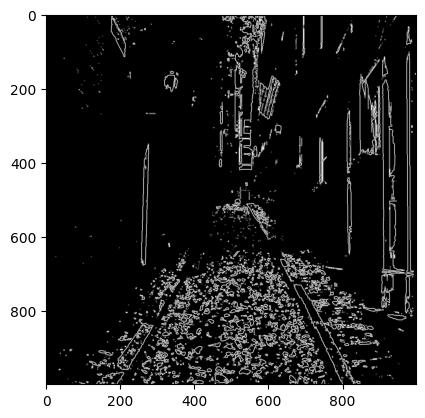

In [462]:
plt.imshow(edges, cmap="gray")

### Hough

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


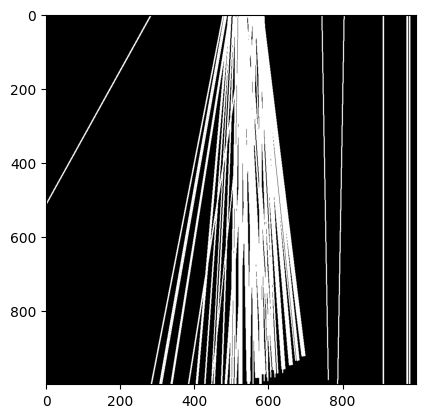

In [463]:
def hough_transform(img, theta_max=180, theta_min=0, threshold=0, n_lines=200):
    M, N = edges.shape
    result = np.zeros((M,N,3))
    num_thetas = (theta_max-theta_min) + 1  # Calculamos la cantidad de elementos en el rango theta_min y theta_max

    r_m = int(np.sqrt(edges.shape[0]**2+edges.shape[1]**2))

    ac = np.zeros((2*r_m+1, num_thetas))

    for i in range(M):
        for j in range(N):
            if edges[i][j] > threshold:
                for theta in range(theta_min, theta_max+1):
                    theta_rad = np.deg2rad(theta)
                    d = int(j *np.cos(theta_rad)-i*np.sin(theta_rad)) + r_m
                    ac[d, theta] += 1

    
    peak = np.argpartition(ac.ravel(), -n_lines)[-n_lines:] ## Donde 10 es el numero de lineas
    peak_2d = np.column_stack(np.unravel_index(peak, ac.shape))

    for rho, theta in peak_2d:
        theta_radians = np.deg2rad(theta)
        a = np.cos(theta_radians)
        b = np.sin(theta_radians)

        rho_t = rho - r_m

        x_0 = a * rho_t
        y_0 = b * rho_t
        x_1 = int(x_0 + 1000 * (-b))
        y_1 = int(y_0 +1000 * (a))
        x_2 = int(x_0 - 1000 * (-b))
        y_2 = int(y_0 -1000 * (a))

        cv.line(result, (x_1, y_1), (x_2, y_2), (255,255,255), 2)

    plt.imshow(result, cmap="gray")

    pass


hough_transform(edges)
                